### One-Dimensional (1D) Bose-Hubbard Model — Example Notebook

This notebook demonstrates using the `bose_hubb` package to simulate bosons hopping on a 1D chain. See `BHmodel_summary.md` for the physics background.

In [1]:
import numpy as np
from IPython.display import HTML

import bose_hubb as bh

Matplotlib is building the font cache; this may take a moment.


#### Build the reduced Hamiltonian

In [2]:
model = bh.ReducedBoseHubbard(L=5, N=5, J=1.0, U=0.0)

print("Number of basis states:", len(model.basis_states))
print("Hamiltonian shape:", model.H.shape)
print("Hamiltonian type:", type(model.H))
print("Hamiltonian is Hermitian:", model.H.isherm)

Number of basis states: 126
Hamiltonian shape: (126, 126)
Hamiltonian type: <class 'qutip.core.qobj.Qobj'>
Hamiltonian is Hermitian: True


#### Run the dynamics

In [9]:
dynamics = bh.BoseHubbardDynamics(model, t_start=0, t_end=10, num_times=300)

psi0, result, site_number_expect, N_expect = dynamics.run_dynamics(
    random_fock_state=True,
    superposition=False,
    user_initial_state=False,
)

print("Initial state as a NumPy array:")
print(psi0.full())

Initial state as a NumPy array:
[[0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [1.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j

In [10]:
from qutip import expect, ket2dm

initial_N = expect(dynamics.N_op, psi0)
print("Expected total number:", initial_N)
print("Correct total number:", np.isclose(initial_N, model.N))

rho0 = ket2dm(psi0)
purity = np.real_if_close((rho0 * rho0).tr())
print("Purity:", purity)
print("Initial state is pure:", np.isclose(purity, 1.0))

Expected total number: 5.0
Correct total number: True
Purity: 1.0
Initial state is pure: True


#### Plots

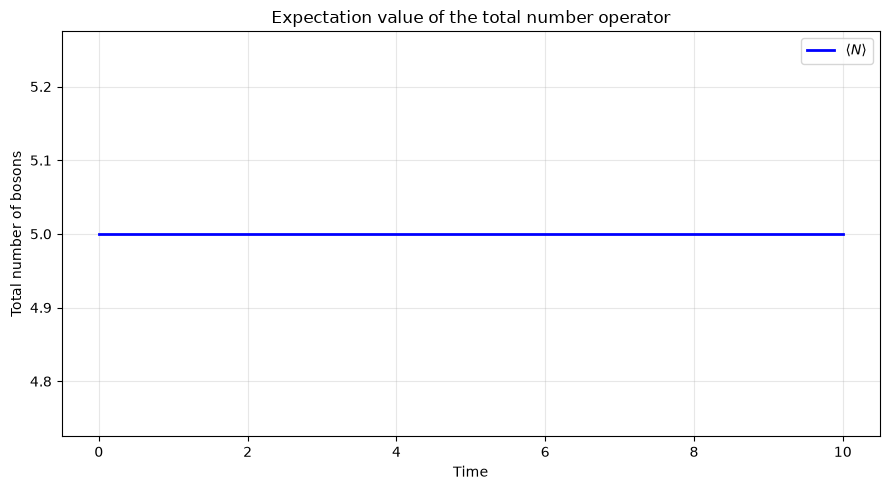

In [11]:
dynamics.plot_total_number(N_expect)

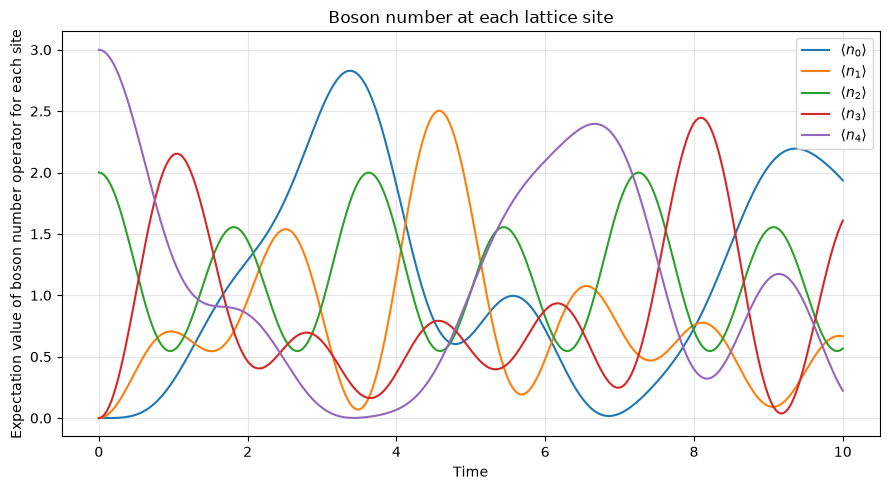

In [12]:
dynamics.plot_site_numbers(site_number_expect)

#### Animation

In [13]:
animation = dynamics.animate_site_numbers(site_number_expect)
HTML(animation.to_jshtml())